# test again C version of 2LPTic

In [13]:
import struct
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def _read_block(f):
    """Read one Fortran-style unformatted block."""
    block_size_start = struct.unpack("<I", f.read(4))[0]
    data = f.read(block_size_start)
    block_size_end = struct.unpack("<I", f.read(4))[0]

    if block_size_start != block_size_end:
        raise IOError(
            f"Block size mismatch: start={block_size_start}, end={block_size_end}"
        )
    return data


def read_gadget_ic(filename):
    """
    Read a Gadget format-1 IC/snapshot file with blocks:
      header, positions, velocities, IDs

    Returns
    -------
    header : dict
    pos : (N, 3) float32 array
    vel : (N, 3) float32 array
    ids : (N,) int32 array
    """
    with open(filename, "rb") as f:
        # -----------------
        # Header block
        # -----------------
        header_bytes = _read_block(f)
        if len(header_bytes) != 256:
            raise ValueError(f"Expected 256-byte header, got {len(header_bytes)} bytes")

        # Gadget header layout
        # 6i, 6d, d, d, i, i, 6i, i, i, d, d, d, d
        fmt = "<6i6dddii6iiidddd"
        header_size = struct.calcsize(fmt)
        raw = struct.unpack(fmt, header_bytes[:header_size])

        i = 0
        npart = np.array(raw[i:i+6], dtype=np.int32); i += 6
        mass = np.array(raw[i:i+6], dtype=np.float64); i += 6
        time = raw[i]; i += 1
        redshift = raw[i]; i += 1
        flag_sfr = raw[i]; i += 1
        flag_feedback = raw[i]; i += 1
        npartTotal = np.array(raw[i:i+6], dtype=np.uint32); i += 6
        flag_cooling = raw[i]; i += 1
        num_files = raw[i]; i += 1
        boxsize = raw[i]; i += 1
        omega0 = raw[i]; i += 1
        omegaLambda = raw[i]; i += 1
        hubble = raw[i]; i += 1

        header = {
            "npart": npart,
            "mass": mass,
            "time": time,
            "redshift": redshift,
            "flag_sfr": flag_sfr,
            "flag_feedback": flag_feedback,
            "npartTotal": npartTotal,
            "flag_cooling": flag_cooling,
            "num_files": num_files,
            "BoxSize": boxsize,
            "Omega0": omega0,
            "OmegaLambda": omegaLambda,
            "HubbleParam": hubble,
        }

        N = int(npart.sum())

        # -----------------
        # Positions block
        # -----------------
        pos_bytes = _read_block(f)
        pos = np.frombuffer(pos_bytes, dtype=np.float32).reshape(N, 3)

        # -----------------
        # Velocities block
        # -----------------
        vel_bytes = _read_block(f)
        vel = np.frombuffer(vel_bytes, dtype=np.float32).reshape(N, 3)

        # -----------------
        # IDs block
        # -----------------
        id_bytes = _read_block(f)
        ids = np.frombuffer(id_bytes, dtype=np.int32)

        if len(ids) != N:
            raise ValueError(f"Expected {N} particle IDs, found {len(ids)}")

    return header, pos, vel, ids


## read in `2LPTicQ` output

In [3]:
header, pos, vel, ids = read_gadget_ic('/Users/ch54662/projects/2LPTicQ/ics')

In [10]:
pos = pos / 1000.

## read in Quijote ICs

In [4]:
from hodalpt.sims import quijote as Q

In [6]:
ics = Q.IC('/Users/ch54662/Downloads/fiducial_LR/0/')

In [7]:
ics.pos

array([[2.2246283e-02, 2.0380540e-02, 9.9996887e+02],
       [2.3255385e-02, 3.0313710e-02, 3.8542156e+00],
       [1.8571563e-02, 2.1722235e-02, 7.7069826e+00],
       ...,
       [9.9606720e+02, 9.9605994e+02, 9.8824512e+02],
       [9.9606714e+02, 9.9604871e+02, 9.9215985e+02],
       [9.9608020e+02, 9.9609003e+02, 9.9605310e+02]],
      shape=(16777216, 3), dtype=float32)

# visual comparison

In [15]:
zlim0 = (pos[:,2] < 5)
zlim1 = (ics.pos[:,2] < 5)

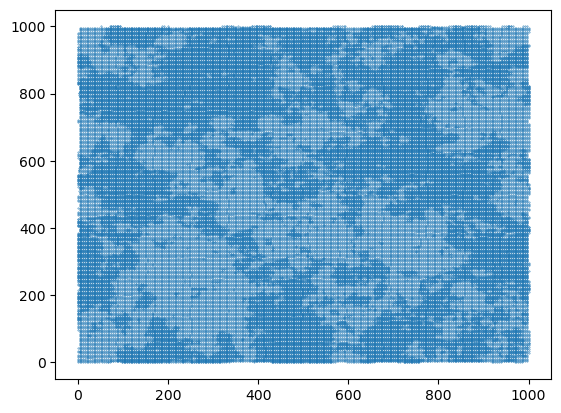

In [16]:
plt.scatter(pos[:,0][zlim0], pos[:,1][zlim0], s=0.1)

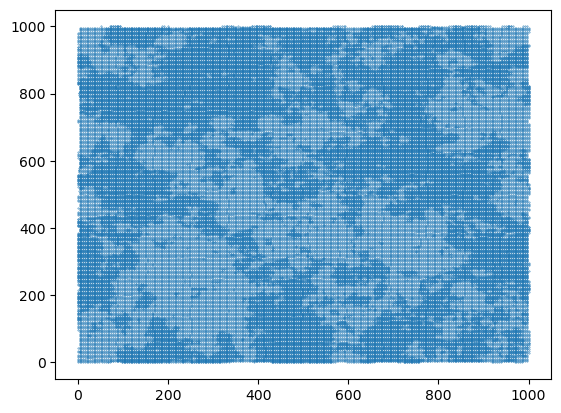

In [18]:
plt.scatter(ics.pos[:,0][zlim1], ics.pos[:,1][zlim1], s=0.1)

nice. Virtually identical

# compare deltas

In [20]:
from hodalpt.sims import alpt as ALPT

In [25]:
delta = ALPT.get_cic(pos[:,0], pos[:,1], pos[:,2], np.ones(pos.shape[0]), 1000., 256)
delta = delta.flatten()
delta = delta/np.mean(delta) - 1.

In [22]:
delta_Q = ALPT._make_ics_quijote('/Users/ch54662/Downloads/fiducial_LR/0/ICs', 1000., 256)

In [31]:
delta

array([ 0.02412804,  0.02093112,  0.00814403, ..., -0.02037148,
        0.00037875,  0.01478153], shape=(16777216,))

In [27]:
delta_Q

array([ 0.024128  ,  0.02093112,  0.00814403, ..., -0.02037147,
        0.00037876,  0.01478151], shape=(16777216,))